# Import

In [ ]:
# Repo-relative paths: inputs are read from imports_stable/, outputs are written to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"
for _d in ["plots/qc_barcode_cutoff", "qc_barcode_cutoff"]:
    os.makedirs(f"{OUTS_DIR}/{_d}", exist_ok=True)

In [1]:
import pandas as pd
import numpy as np
import h5py
from anndata.io import read_elem
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

PLOT_DIR = OUTS_DIR + "/plots/qc_barcode_cutoff"
OUT_DIR = OUTS_DIR + "/qc_barcode_cutoff"

In [2]:
f = h5py.File(IMPORTS_DIR + "/SIG13/scanpy_outs/SIG13_full_bc_processed.h5mu", "r")
bc = read_elem(f["mod"]["bc"])
bc


AnnData object with n_obs × n_vars = 628244 × 74
    obs: 'lane'
    layers: 'counts', 'dsb'

# Barcode Calling Rates Across DSB Cutoffs

Sweep the DSB cutoff from 1 to 10 and look at the singlet/doublet/multiplet tradeoff, as fractions and counts of *all* cells in `bc`.

## Feature-calling helpers

In [3]:
def generate_feature_calls(adata, umi_threshold=2):
    """
    Generate feature calls for each cell in the AnnData object based on UMI counts.

    Parameters:
    - adata: AnnData object with cells in .obs and features in .var
    - umi_threshold: int, the minimum UMI count to call a feature for a cell (default is 2)

    Returns:
    - A DataFrame with columns: cell_barcode, num_features, num_umis, feature_call
    """
    X = adata.X
    # Handle both sparse and dense matrices
    if hasattr(X, "tocoo"):
        # Sparse matrix
        non_zero_entries = X >= umi_threshold
        rows, cols = non_zero_entries.nonzero()
        umi_counts = X[rows, cols].A1
    else:
        # Dense matrix (numpy ndarray)
        non_zero_entries = X >= umi_threshold
        rows, cols = non_zero_entries.nonzero()
        umi_counts = X[rows, cols]

    # Map rows and columns to cell and feature names
    cell_ids = adata.obs.index[rows]
    feature_names = adata.var.index[cols]

    # Create a DataFrame of these results to group by cell
    data = pd.DataFrame({
        "cell_barcode": cell_ids,
        "feature_name": feature_names,
        "umi_count": umi_counts
    })

    # Group by cell and aggregate features and UMIs
    grouped_data = data.groupby("cell_barcode").agg({
        "feature_name": lambda x: "|".join(x),
        "umi_count": lambda x: "|".join(map(str, x))
    }).reset_index()

    # Add the number of features column
    grouped_data["num_features"] = grouped_data["feature_name"].str.count(r"\|") + 1

    # Rename columns to match desired output
    grouped_data = grouped_data.rename(columns={
        "feature_name": "feature_call",
        "umi_count": "num_umis"
    })

    return grouped_data


In [4]:
def process_feature_call(df, feature_call_col="feature_call"):
    # Fill NaNs early and create mask for NaNs
    feature_calls = df[feature_call_col].fillna("")
    split_calls = feature_calls.str.split("|")

    ligand_calls = []
    group_calls = []

    for calls in split_calls:
        if calls == [""]:
            ligand_calls.append("")
            group_calls.append("")
        else:
            ligands = [c.rsplit("_", 1)[0] for c in calls]
            groups = [c.rsplit("_", 1)[-1] for c in calls]
            ligand_calls.append("_".join(ligands))
            group_calls.append("_".join(sorted(groups)))

    df["ligand_call"] = ligand_calls
    df["group_call"] = group_calls
    return df


## Sweep cutoffs 1-10

In [5]:
# Shared category colors, used by every figure in Parts A/A2/A3
CAT_COLORS = {"singlet": "C0", "doublet": "C1", "multiplet": "C3", "uncalled": "C4"}
CAT_ORDER = ["singlet", "doublet", "multiplet", "uncalled"]

n_total = bc.n_obs
cutoff_rows = []
calls_by_cutoff = {}  # reused by Parts A2/A3 to avoid a second pass over bc.X
for t in range(1, 11):
    calls = generate_feature_calls(bc, umi_threshold=t)
    calls = process_feature_call(calls)
    calls_by_cutoff[t] = calls.set_index("cell_barcode")[
        ["num_features", "feature_call", "group_call"]
    ]
    n_called = len(calls)
    singlet = (calls["num_features"] == 1).sum()
    doublet = (calls["num_features"] == 2).sum()
    multiplet = (calls["num_features"] > 2).sum()
    cutoff_rows.append({
        "cutoff": t,
        "singlet": singlet,
        "doublet": doublet,
        "multiplet": multiplet,
        "uncalled": n_total - n_called,
        "singlet_pct": singlet / n_total * 100,
        "doublet_pct": doublet / n_total * 100,
        "multiplet_pct": multiplet / n_total * 100,
        "uncalled_pct": (n_total - n_called) / n_total * 100,
    })

cutoff_df = pd.DataFrame(cutoff_rows)
cutoff_df.to_csv(f"{OUT_DIR}/barcode_calling_rate_vs_cutoff.csv", index=False)
cutoff_df

,cutoff,singlet,doublet,multiplet,uncalled,singlet_pct,doublet_pct,multiplet_pct,uncalled_pct
0,1,2788,82719,542221,516,0.443777,13.166700,86.307390,0.082134
1,2,8647,164166,453862,1569,1.376376,26.130930,72.242950,0.249744
2,3,19534,258496,346382,3832,3.109301,41.145797,55.134948,0.609954
3,4,37643,335652,247382,7567,5.991780,53.427012,39.376739,1.204468
4,5,63055,379215,172528,13446,10.036705,60.361102,27.461942,2.140251
5,6,97096,386018,122818,22312,15.455142,61.443961,19.549411,3.551486
6,7,139899,362267,90716,35362,22.268259,57.663424,14.439613,5.628705
7,8,190584,315156,68018,54486,30.335984,50.164586,10.826685,8.672745
8,9,243327,254219,49533,81165,38.731289,40.465010,7.884357,12.919343
9,10,288101,189786,34078,116279,45.858138,30.208963,5.424326,18.508573


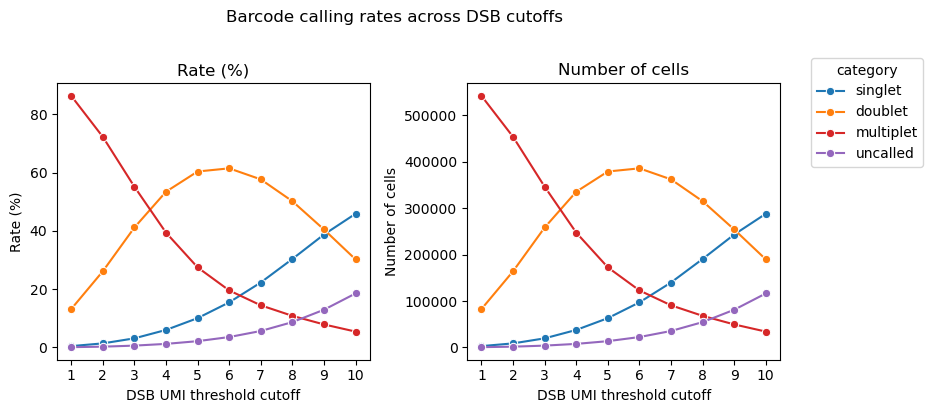

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8,4), sharex=True)

pct_order = [f"{c}_pct" for c in CAT_ORDER]
pct_palette = {f"{c}_pct": CAT_COLORS[c] for c in CAT_ORDER}

# --- Panel 1: percentages ---
plot_df_pct = cutoff_df.melt(
    id_vars="cutoff", value_vars=pct_order,
    var_name="category", value_name="rate_pct"
)
sns.lineplot(data=plot_df_pct, x="cutoff", y="rate_pct", hue="category", marker="o",
             hue_order=pct_order, palette=pct_palette, ax=axes[0], legend=False)
axes[0].set_xlabel("DSB UMI threshold cutoff")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Rate (%)")
axes[0].set_xticks(range(1, 11))

# --- Panel 2: counts ---
plot_df_num = cutoff_df.melt(
    id_vars="cutoff", value_vars=CAT_ORDER,
    var_name="category", value_name="cell_num"
)
g2 = sns.lineplot(data=plot_df_num, x="cutoff", y="cell_num", hue="category", marker="o",
                  hue_order=CAT_ORDER, palette=CAT_COLORS, ax=axes[1])
axes[1].set_xlabel("DSB UMI threshold cutoff")
axes[1].set_ylabel("Number of cells")
axes[1].set_title("Number of cells")
axes[1].set_xticks(range(1, 11))

# Single shared legend on the right, using panel 2's handles
handles, labels = axes[1].get_legend_handles_labels()
axes[1].get_legend().remove()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.9), loc="upper left",
           borderaxespad=0., title="category")

fig.suptitle("Barcode calling rates across DSB cutoffs", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barcode_calling_rate_vs_cutoff_combined.pdf", bbox_inches="tight")
plt.show()

# Doublet-Call Stability Across DSB Cutoffs

Category counts don't show *whether they are the same cells*. Fix DSB7 (the production cutoff) as the reference and ask, for DSB4/5/6/8, what fraction of the doublet population is shared, and where the non-shared cells go.

Feature calling is monotone in the threshold, so a cell called a doublet at two cutoffs necessarily carries the same barcode pair; identity concordance is a sanity check, not a result.

In [7]:
REF_CUTOFF = 7
ALT_CUTOFFS = [4, 5, 6, 8]

all_cells = pd.Index(bc.obs_names)


def category_series(t):
    """Per-cell call category at DSB cutoff `t`, over *all* cells in `bc`."""
    c = calls_by_cutoff[t]
    cat = pd.Series("multiplet", index=c.index, dtype=object)
    cat[c["num_features"] == 1] = "singlet"
    cat[c["num_features"] == 2] = "doublet"
    return cat.reindex(all_cells, fill_value="uncalled")


def doublet_index(t):
    """Cell barcodes called doublet at cutoff `t`."""
    c = calls_by_cutoff[t]
    return c.index[c["num_features"] == 2]


cats = {t: category_series(t) for t in [REF_CUTOFF] + ALT_CUTOFFS}

overlap_rows = []
identity_violations = 0
ref = doublet_index(REF_CUTOFF)
ref_calls = calls_by_cutoff[REF_CUTOFF].loc[ref, "feature_call"]
for t in ALT_CUTOFFS:
    alt = doublet_index(t)
    shared = ref.intersection(alt)
    # monotonicity check: same cell, same two barcodes at both cutoffs
    alt_calls = calls_by_cutoff[t].loc[shared, "feature_call"]
    identity_violations += int(
        (alt_calls.values != ref_calls.loc[shared].values).sum()
    )
    union = len(ref) + len(alt) - len(shared)
    overlap_rows.append({
        "cutoff": t,
        "n_ref_DSB7": len(ref),
        "n_alt": len(alt),
        "n_shared": len(shared),
        "frac_of_ref_shared": len(shared) / len(ref),
        "frac_of_alt_shared": len(shared) / len(alt) if len(alt) else np.nan,
        "jaccard": len(shared) / union if union else np.nan,
    })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(f"{OUT_DIR}/doublet_call_overlap_vs_DSB7.csv", index=False)
print(f"barcode-pair identity mismatches among shared doublets: {identity_violations}")
overlap_df

barcode-pair identity mismatches among shared doublets: 0


,cutoff,n_ref_DSB7,n_alt,n_shared,frac_of_ref_shared,frac_of_alt_shared,jaccard
0,4,362267,335652,241865,0.667643,0.720583,0.530343
1,5,362267,379215,295425,0.815490,0.779044,0.662303
2,6,362267,386018,333592,0.920846,0.864188,0.804431
3,8,362267,315156,295357,0.815302,0.937177,0.773052


In [8]:
# Where do the non-shared cells go? Fate of DSB7 doublets at each comparator
# cutoff, and the mirror direction (what the comparator's doublets were at DSB7).
FATE_CATS = ["singlet", "doublet", "multiplet", "uncalled"]

fate_rows = []
ref = doublet_index(REF_CUTOFF)
for t in ALT_CUTOFFS:
    alt = doublet_index(t)
    for direction, source, target_cats in [
        (f"DSB7 doublet -> DSB{t}", ref, cats[t]),
        (f"DSB{t} doublet -> DSB7", alt, cats[REF_CUTOFF]),
    ]:
        vc = target_cats.loc[source].value_counts()
        row = {"direction": direction, "cutoff": t, "n_source": len(source)}
        for cat in FATE_CATS:
            row[cat] = int(vc.get(cat, 0))
            row[f"{cat}_pct"] = row[cat] / len(source) * 100
        fate_rows.append(row)

fate_df = pd.DataFrame(fate_rows)
fate_df.to_csv(f"{OUT_DIR}/doublet_call_fate_vs_DSB7.csv", index=False)
fate_df


,direction,cutoff,n_source,singlet,singlet_pct,doublet,doublet_pct,multiplet,multiplet_pct,uncalled,uncalled_pct
0,DSB7 doublet -> DSB4,4,362267,0,0.000000,241865,66.764293,120402,33.235707,0,0.000000
1,DSB4 doublet -> DSB7,4,335652,82374,24.541489,241865,72.058263,0,0.000000,11413,3.400248
2,DSB7 doublet -> DSB5,5,362267,0,0.000000,295425,81.548968,66842,18.451032,0,0.000000
3,DSB5 doublet -> DSB7,5,379215,76992,20.302994,295425,77.904355,0,0.000000,6798,1.792651
4,DSB7 doublet -> DSB6,6,362267,0,0.000000,333592,92.084567,28675,7.915433,0,0.000000
5,DSB6 doublet -> DSB7,6,386018,50244,13.015973,333592,86.418768,0,0.000000,2182,0.565259
6,DSB7 doublet -> DSB8,8,362267,64113,17.697720,295357,81.530197,0,0.000000,2797,0.772082
7,DSB8 doublet -> DSB7,8,315156,0,0.000000,295357,93.717714,19799,6.282286,0,0.000000


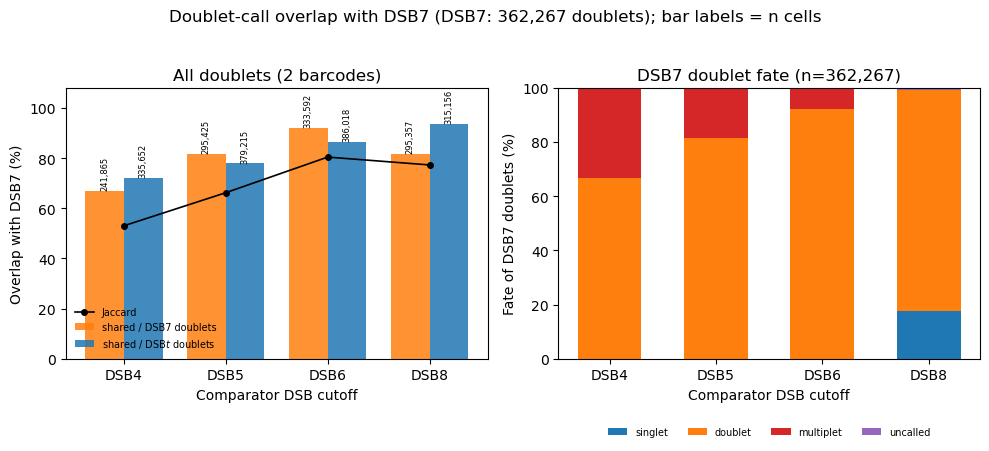

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Panel A: set overlap of the doublet population with DSB7
sub = overlap_df.set_index("cutoff")
x = np.arange(len(ALT_CUTOFFS))
w = 0.38
for col, ncol, label, color, off in [
    ("frac_of_ref_shared", "n_shared", "shared / DSB7 doublets", "C1", -w / 2),
    ("frac_of_alt_shared", "n_alt", "shared / DSB$t$ doublets", "C0", w / 2),
]:
    vals = sub.loc[ALT_CUTOFFS, col].values * 100
    axes[0].bar(x + off, vals, width=w, label=label, color=color, alpha=0.85)
    for xi, v, n in zip(x + off, vals, sub.loc[ALT_CUTOFFS, ncol].values):
        axes[0].annotate(f"{n:,}", (xi, v), textcoords="offset points",
                         xytext=(0, 2), ha="center", fontsize=6, rotation=90)
axes[0].plot(x, sub.loc[ALT_CUTOFFS, "jaccard"].values * 100, "o-", color="k",
             lw=1.2, ms=4, label="Jaccard")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"DSB{t}" for t in ALT_CUTOFFS])
axes[0].set_xlabel("Comparator DSB cutoff")
axes[0].set_ylabel("Overlap with DSB7 (%)")
axes[0].set_ylim(0, 108)
axes[0].set_title("All doublets (2 barcodes)")
axes[0].legend(fontsize=7, loc="lower left", frameon=False)

# Panel B: fate of the DSB7 doublet population at each comparator cutoff
fate_ref = fate_df[fate_df["direction"].str.startswith("DSB7 doublet")].set_index("cutoff")
bottom = np.zeros(len(ALT_CUTOFFS))
for cat in FATE_CATS:
    vals = fate_ref.loc[ALT_CUTOFFS, f"{cat}_pct"].values
    axes[1].bar(x, vals, bottom=bottom, width=0.6, label=cat, color=CAT_COLORS[cat])
    bottom += vals
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"DSB{t}" for t in ALT_CUTOFFS])
axes[1].set_xlabel("Comparator DSB cutoff")
axes[1].set_ylabel("Fate of DSB7 doublets (%)")
axes[1].set_ylim(0, 100)
axes[1].set_title(f"DSB7 doublet fate (n={fate_ref['n_source'].iloc[0]:,})")
axes[1].legend(fontsize=7, ncol=4, frameon=False,
               loc="upper center", bbox_to_anchor=(0.5, -0.22))

n_ref_all = overlap_df["n_ref_DSB7"].iloc[0]
fig.suptitle(
    f"Doublet-call overlap with DSB7 (DSB7: {n_ref_all:,} doublets); bar labels = n cells",
    y=1.03,
)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/doublet_call_overlap_vs_DSB7.pdf", bbox_inches="tight")
plt.show()

# Barcode-Score Spread Within Cells Across DSB Cutoffs

How *evenly* are the called barcodes within a cell detected? This separates genuine co-delivery from one dominant barcode plus ambient/spillover signal.

**Max spread among called barcodes** (doublet and multiplet cells): the top called barcode's DSB score minus the lowest called one. A doublet scoring 20 and 7.1 is a very different object from one scoring 12 and 11.

In [10]:
# Descending per-cell sort of the DSB matrix: S[:, k] is the (k+1)-th highest
# score in that cell. Everything in Part A3 is a lookup into this array.
S = np.sort(np.asarray(bc.X), axis=1)[:, ::-1]
CUTOFFS = list(range(1, 11))

# the top-1 / top-2 barcode DSB counts metric below
top1_umi = S[:, 0]
top2_umi = S[:, 1]

# Per-cutoff number of called features, and a sanity check against Part A's calls.
n_feat_by_cutoff = {t: (S >= t).sum(axis=1) for t in CUTOFFS}
for t in CUTOFFS:
    ref_nf = calls_by_cutoff[t]["num_features"].reindex(all_cells, fill_value=0)
    assert (n_feat_by_cutoff[t] == ref_nf.values).all(), f"feature-count mismatch at DSB{t}"
print("sorted-matrix feature counts match generate_feature_calls at all cutoffs")

sorted-matrix feature counts match generate_feature_calls at all cutoffs


## Max spread among called barcodes

In [11]:
def summarize(values, **fixed):
    """mean / median / IQR summary of a 1-D array, plus identifying columns."""
    row = dict(fixed, n=int(values.size))
    if values.size:
        row.update(mean=float(np.mean(values)), median=float(np.median(values)),
                   q25=float(np.percentile(values, 25)),
                   q75=float(np.percentile(values, 75)),
                   sd=float(np.std(values, ddof=1)) if values.size > 1 else np.nan)
    else:
        row.update(mean=np.nan, median=np.nan, q25=np.nan, q75=np.nan, sd=np.nan)
    return row


spread_rows = []
for t in CUTOFFS:
    nf = n_feat_by_cutoff[t]
    multi = nf >= 2
    # lowest *called* barcode = the nf-th highest score in the cell
    lowest_called = np.take_along_axis(S[multi], (nf[multi] - 1)[:, None], axis=1).ravel()
    spread = S[multi, 0] - lowest_called
    nf_multi = nf[multi]
    for cat, mask in [("doublet", nf_multi == 2), ("multiplet", nf_multi > 2),
                      ("doublet+multiplet", np.ones(nf_multi.size, dtype=bool))]:
        spread_rows.append(summarize(spread[mask], cutoff=t, category=cat))

spread_df = pd.DataFrame(spread_rows)
spread_df.to_csv(f"{OUT_DIR}/barcode_spread_called_vs_cutoff.csv", index=False)
spread_df[spread_df["category"] != "doublet+multiplet"].pivot(
    index="cutoff", columns="category", values=["n", "mean", "median"]
)

n                mean               median           
category   doublet multiplet   doublet  multiplet   doublet  multiplet
cutoff                                                                
1          82719.0  542221.0  4.757093  11.810506  4.482545  12.023146
2         164166.0  453862.0  4.771282  10.744293  4.488767  10.916365
3         258496.0  346382.0  4.773023   9.718955  4.518357   9.831448
4         335652.0  247382.0  4.736101   8.773712  4.514459   8.806025
5         379215.0  172528.0  4.675611   7.938672  4.484902   7.920606
6         386018.0  122818.0  4.591714   7.244642  4.429179   7.207849
7         362267.0   90716.0  4.481337   6.675598  4.336984   6.634878
8         315156.0   68018.0  4.337745   6.184947  4.199925   6.142354
9         254219.0   49533.0  4.149213   5.713991  4.000994   5.646620
10        189786.0   34078.0  3.888336   5.267377  3.705372   5.164923

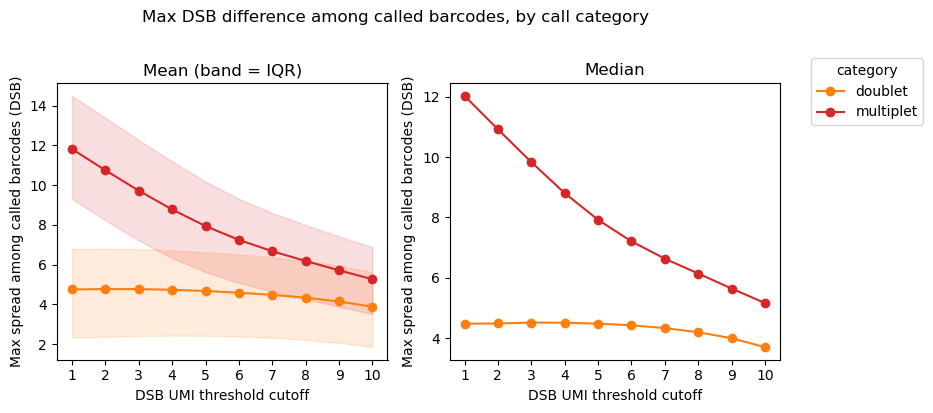

In [12]:
SPREAD_CATS = ["doublet", "multiplet"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True)

# --- Panel 1: mean spread, with IQR band ---
for cat in SPREAD_CATS:
    sub = spread_df[spread_df["category"] == cat].set_index("cutoff").loc[CUTOFFS]
    axes[0].fill_between(CUTOFFS, sub["q25"], sub["q75"], color=CAT_COLORS[cat], alpha=0.15)
    axes[0].plot(CUTOFFS, sub["mean"], marker="o", color=CAT_COLORS[cat], label=cat)
axes[0].set_xlabel("DSB UMI threshold cutoff")
axes[0].set_ylabel("Max spread among called barcodes (DSB)")
axes[0].set_title("Mean (band = IQR)")
axes[0].set_xticks(CUTOFFS)

# --- Panel 2: median spread ---
for cat in SPREAD_CATS:
    sub = spread_df[spread_df["category"] == cat].set_index("cutoff").loc[CUTOFFS]
    axes[1].plot(CUTOFFS, sub["median"], marker="o", color=CAT_COLORS[cat], label=cat)
axes[1].set_xlabel("DSB UMI threshold cutoff")
axes[1].set_ylabel("Max spread among called barcodes (DSB)")
axes[1].set_title("Median")
axes[1].set_xticks(CUTOFFS)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.9), loc="upper left",
           borderaxespad=0., title="category")

fig.suptitle("Max DSB difference among called barcodes, by call category", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barcode_spread_called_vs_cutoff.pdf", bbox_inches="tight")
plt.show()

# Representative Histograms

In [13]:
# Convert the DSB counts for all features to a DataFrame
bc_df = pd.DataFrame(bc.layers['dsb'], columns=bc.var_names, index=bc.obs_names)

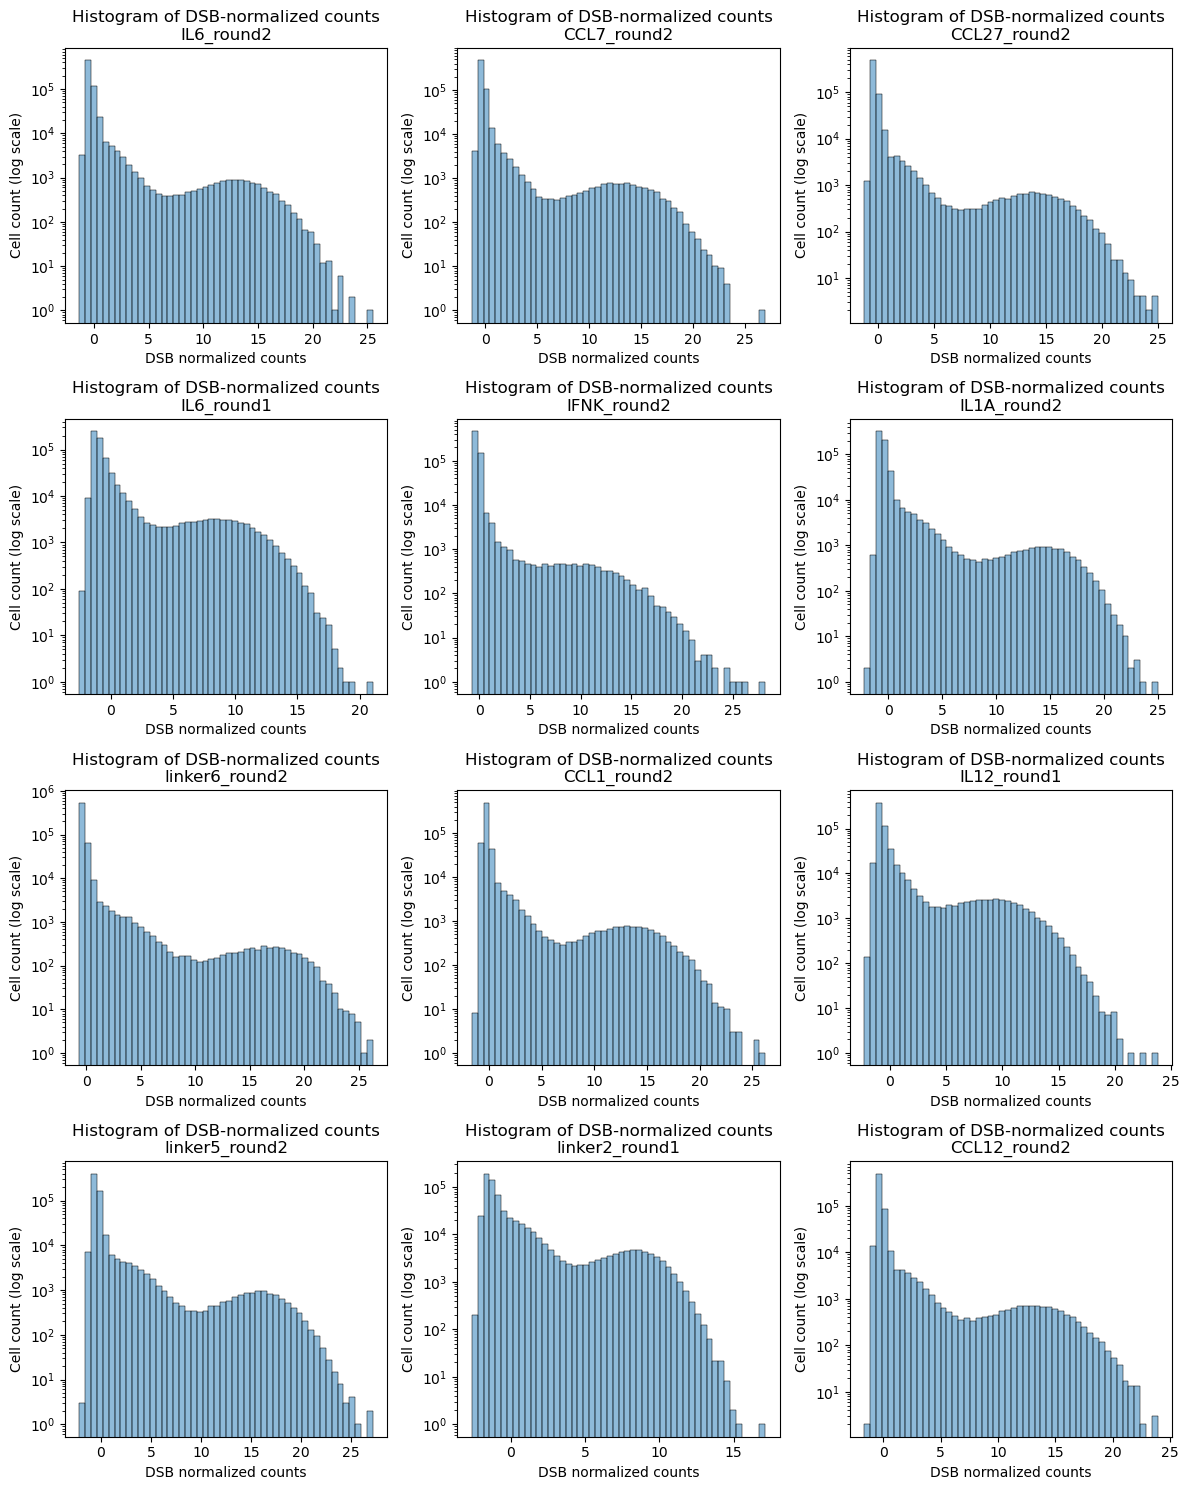

In [14]:
# Select 9 random features
features = np.random.choice(bc_df.columns[:-1], size=12, replace=False)

# Set up 3×3 figure
fig, axes = plt.subplots(4, 3, figsize=(12, 15))
for ax, feat in zip(axes.flatten(), features):
    sns.histplot(data=bc_df, x=feat, bins=50, kde=False, ax=ax, multiple="stack", alpha=0.5)
    ax.set_yscale('log')
    ax.set_xlabel('DSB normalized counts')
    ax.set_ylabel("Cell count (log scale)")
    ax.set_title(f"Histogram of DSB-normalized counts\n{feat}")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barcode_calling_representative_histograms.pdf", bbox_inches="tight")
plt.show()

# Position and Ligand-Identity Bias in the Two Called Barcodes (DSB7)

Within the production DSB7 doublet population (`SIG13_doublets_DSB7.h5ad`), is detection of the two called barcodes biased by position (round1 vs. round2) or by ligand identity?

In [15]:
rna = sc.read_h5ad(IMPORTS_DIR + "/SIG13/scanpy_outs/SIG13_doublets_DSB7.h5ad")
rna

# separate out obs
obs = rna.obs.copy()

In [16]:
feature_split = obs["feature_call_DSB7"].astype(str).str.split("|", expand=True)
obs['feature_call_round1_DSB7'] = feature_split[0]
obs['feature_call_round2_DSB7'] = feature_split[1]

In [17]:
# split the "round1_score|round2_score" string into two numeric columns
score_split = obs["num_umis_DSB7"].astype(str).str.split("|", expand=True).astype(float)
obs["round1_score_DSB7"] = score_split[0]
obs["round2_score_DSB7"] = score_split[1]
obs[["round1_score_DSB7", "round2_score_DSB7"]].describe()


,round1_score_DSB7,round2_score_DSB7
count,349678.000000,349678.000000
mean,10.133886,14.333093
std,2.100348,3.227753
min,7.000003,7.000026
25%,8.490516,12.063182
50%,9.804187,14.426406
75%,11.412104,16.631860
max,24.710029,27.273987


## Position bias: round1 vs. round2 called-barcode DSB score

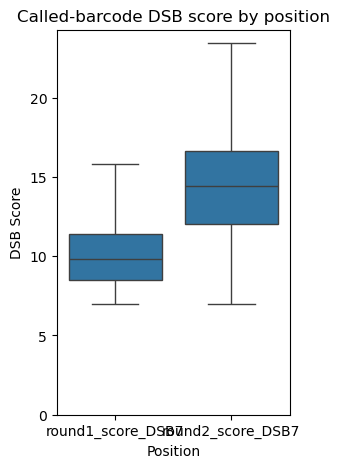

In [18]:
pos_df = obs[["round1_score_DSB7", "round2_score_DSB7"]].melt(var_name="position", value_name="dsb_score")

plt.figure(figsize=(3, 5))
g = sns.boxplot(data=pos_df, x="position", y="dsb_score", showfliers=False)
g.set_title("Called-barcode DSB score by position")
g.set_xlabel("Position")
g.set_ylabel("DSB Score")
g.set_ylim(0, None)
plt.savefig(f"{PLOT_DIR}/barcode_position_bias_boxplot.pdf", bbox_inches="tight")
plt.show()

Round2 barcodes score systematically **higher** than round1 barcodes within the same cell


## Ligand-identity bias

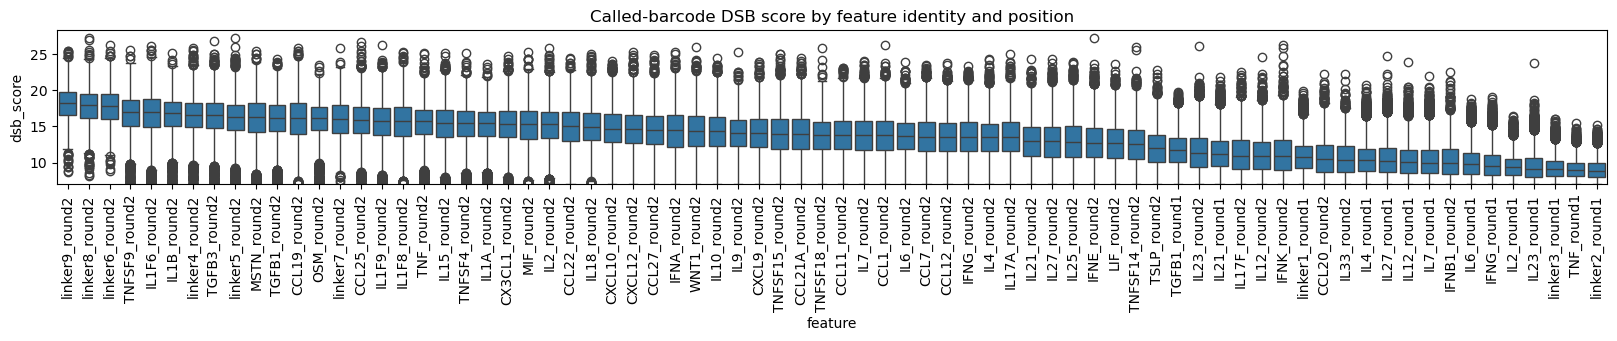

In [19]:
round1_df = obs[["feature_call_round1_DSB7", "ligand_call_round1_DSB7", "round1_score_DSB7"]].rename(
    columns={"feature_call_round1_DSB7": "feature",
             "ligand_call_round1_DSB7": "ligand",
             "round1_score_DSB7": "dsb_score"})
round1_df["position"] = "round1"
round2_df = obs[["feature_call_round2_DSB7", "ligand_call_round2_DSB7", "round2_score_DSB7"]].rename(
    columns={"feature_call_round2_DSB7": "feature",
             "ligand_call_round2_DSB7": "ligand",
             "round2_score_DSB7": "dsb_score"})
round2_df["position"] = "round2"
ligand_score_df = pd.concat([round1_df, round2_df], ignore_index=True)

order = ligand_score_df.groupby("feature", observed=True)["dsb_score"].median().sort_values(ascending=False).index

plt.figure(figsize=(20, 2))
g = sns.boxplot(data=ligand_score_df, x="feature", y="dsb_score",
                 order=order, dodge=True)
g.set_ylim(7, None)
plt.xticks(rotation=90)
g.set_title("Called-barcode DSB score by feature identity and position")
plt.savefig(f"{PLOT_DIR}/dsb_by_ligand_boxplot.pdf", bbox_inches="tight")
plt.show()


In [20]:
ligand_medians = (
    ligand_score_df.groupby(["position", "ligand"], observed=True)["dsb_score"]
    .agg(["median", "count"])
    .reset_index()
    .sort_values("median", ascending=False)
)
ligand_medians.to_csv(f"{OUT_DIR}/barcode_ligand_position_median_scores.csv", index=False)

# ligands present in both pools: direct, identity-controlled position comparison
both_ligands = sorted(set(round1_df["ligand"].unique()) & set(round2_df["ligand"].unique()))
shared_pivot = (
    ligand_medians[ligand_medians["ligand"].isin(both_ligands)]
    .pivot(index="ligand", columns="position", values="median")
    .dropna()
    .sort_values("round1")
)
shared_pivot["round2_minus_round1"] = shared_pivot["round2"] - shared_pivot["round1"]
shared_pivot.to_csv(f"{OUT_DIR}/barcode_shared_ligand_position_comparison.csv")
shared_pivot


position,round1,round2,round2_minus_round1
ligand,,,
TNF,9.030507,15.679038,6.648530
IL23,9.084488,11.310147,2.225659
IL2,9.313463,15.268002,5.954539
linker,9.430008,16.890100,7.460092
IFNG,9.508236,13.564308,4.056071
IL6,9.780837,13.701187,3.920350
IL7,9.983572,13.787212,3.803640
IL12,10.037073,10.924388,0.887315
IL27,10.234861,12.911702,2.676842


Every ligand present in both pools scores higher as a round2 barcode than as a round1 barcode, but the size of the gap varies substantially. Since even the shared `linker` controls (which aren't biological ligands) show one of the largest gaps, the dominant effect is the round1-vs-round2 library/position itself rather than ligand biology.


# Barcode UMI Depth vs. RNA Library Size

The DSB score is partly a property of the *cell*: a more deeply sequenced cell yields more barcode UMIs, so its called-barcode DSB score can rise with total RNA content even when VLP delivery is identical.

In [21]:
# scipy correlation functions used only in Part C (Part B needs just `wilcoxon`, imported above)
from scipy.stats import spearmanr, pearsonr

obs["mean_barcode_score_DSB7"] = obs[["round1_score_DSB7", "round2_score_DSB7"]].mean(axis=1)

score_vars = ["mean_barcode_score_DSB7", "round1_score_DSB7", "round2_score_DSB7"]
depth_vars = ["log1p_total_counts", "n_genes_by_counts", "log1p_total_counts_bc", "pct_counts_mt"]

corr_rows = []
for s in score_vars:
    for d in depth_vars:
        rho, p_rho = spearmanr(obs[s], obs[d])
        r, p_r = pearsonr(obs[s], obs[d])
        corr_rows.append({"barcode_score": s, "depth_measure": d,
                          "spearman": rho, "spearman_p": p_rho,
                          "pearson": r, "pearson_p": p_r})

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(f"{OUT_DIR}/barcode_score_vs_library_size_correlations.csv", index=False)
corr_df

,barcode_score,depth_measure,spearman,spearman_p,pearson,pearson_p
0,mean_barcode_score_DSB7,log1p_total_counts,0.292310,0.000000e+00,0.297673,0.000000e+00
1,mean_barcode_score_DSB7,n_genes_by_counts,0.284364,0.000000e+00,0.289818,0.000000e+00
2,mean_barcode_score_DSB7,log1p_total_counts_bc,0.812715,0.000000e+00,0.821834,0.000000e+00
3,mean_barcode_score_DSB7,pct_counts_mt,0.055902,5.243474e-240,0.042132,3.999216e-137
4,round1_score_DSB7,log1p_total_counts,0.244295,0.000000e+00,0.244507,0.000000e+00
5,round1_score_DSB7,n_genes_by_counts,0.233925,0.000000e+00,0.234176,0.000000e+00
6,round1_score_DSB7,log1p_total_counts_bc,0.507795,0.000000e+00,0.530551,0.000000e+00
7,round1_score_DSB7,pct_counts_mt,0.054110,5.631843e-225,0.045507,1.150793e-159
8,round2_score_DSB7,log1p_total_counts,0.245458,0.000000e+00,0.250018,0.000000e+00
9,round2_score_DSB7,n_genes_by_counts,0.241221,0.000000e+00,0.245944,0.000000e+00


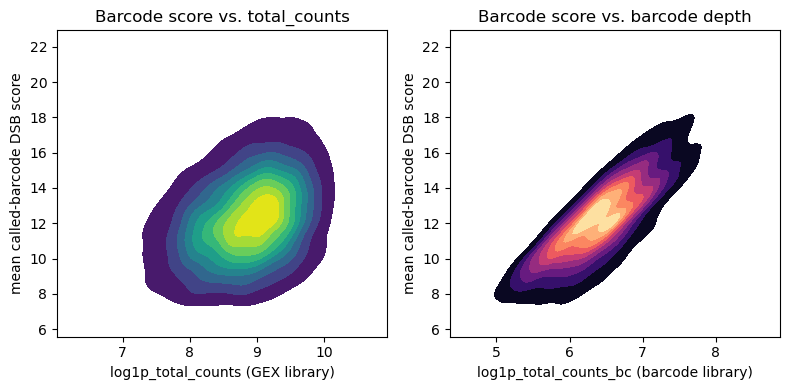

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8,4))

# Randomly subsample 10,000 cells for each plot
obs_tc = obs.sample(n=min(10000, len(obs)), random_state=42)
obs_bc = obs.sample(n=min(10000, len(obs)), random_state=42)

sns.kdeplot(
    data=obs_tc,
    x="log1p_total_counts",
    y="mean_barcode_score_DSB7",
    fill=True,
    cmap="viridis",
    levels=10,
    thresh=0.05,
    ax=axes[0],
)
axes[0].set_xlabel("log1p_total_counts (GEX library)")
axes[0].set_ylabel("mean called-barcode DSB score")
axes[0].set_title("Barcode score vs. total_counts")

sns.kdeplot(
    data=obs_bc,
    x="log1p_total_counts_bc",
    y="mean_barcode_score_DSB7",
    fill=True,
    cmap="magma",
    levels=10,
    thresh=0.05,
    ax=axes[1],
)
axes[1].set_xlabel("log1p_total_counts_bc (barcode library)")
axes[1].set_ylabel("mean called-barcode DSB score")
axes[1].set_title("Barcode score vs. barcode depth")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barcode_score_vs_library_size.pdf", bbox_inches="tight")
plt.show()